In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Định nghĩa Transform cho tập huấn luyện (có Augmentation)
train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Transform cho tập kiểm tra (chỉ chuẩn hóa, không Augmentation)
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Tải dữ liệu MNIST
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1000, shuffle=False)

100.0%
100.0%
100.0%
100.0%


- Việc thêm RandomAffine giúp mô hình học được các biến thể của chữ số (nghiêng, lệch). Điều này ngăn chặn mô hình "học vẹt" vị trí pixel, từ đó cải thiện khả năng nhận diện các chữ số viết tay thực tế vốn không bao giờ hoàn hảo và nằm chính giữa khung hình.

In [2]:
class HomeworkCNN(nn.Module):
    def __init__(self):
        super(HomeworkCNN, self).__init__()
        # Câu 1: Các tầng Conv
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        
        # Câu 5: Thêm Dropout p=0.25 trước khi vào tầng Full Connected
        self.dropout = nn.Dropout(p=0.25)
        
        # Sau 2 lần Pooling, ảnh 28x28 thành 7x7
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        
        x = x.view(-1, 32 * 7 * 7) # Flatten
        x = self.dropout(x)        # Áp dụng Dropout
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = HomeworkCNN()

Số lượng tham số (Parameters) được tính như sau:
- Conv1: $(3 \times 3 \times 1 \text{ input} \times 16 \text{ filters}) + 16 \text{ bias} = 160$.
- Conv2: $(3 \times 3 \times 16 \text{ input} \times 32 \text{ filters}) + 32 \text{ bias} = 4,640$.
- FC1: $(32 \times 7 \times 7 \text{ features}) \times 128 \text{ nodes} + 128 \text{ bias} = 200,832$.
- FC2: $(128 \times 10) + 10 \text{ bias} = 1,290$.

Nhận xét: Các tầng tích chập (Conv) có rất ít tham số nhờ cơ chế chia sẻ trọng số, trong khi các tầng FC chiếm phần lớn dung lượng mô hình.

In [3]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Vòng lặp huấn luyện (ví dụ 10 epoch)
def train(epochs=10):
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in trainloader:
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        print(f"Epoch {epoch+1} - Loss trung bình: {total_loss/len(trainloader):.4f}")

train()

Epoch 1 - Loss trung bình: 0.3639
Epoch 2 - Loss trung bình: 0.1252
Epoch 3 - Loss trung bình: 0.0922
Epoch 4 - Loss trung bình: 0.0781
Epoch 5 - Loss trung bình: 0.0697
Epoch 6 - Loss trung bình: 0.0634
Epoch 7 - Loss trung bình: 0.0606
Epoch 8 - Loss trung bình: 0.0572
Epoch 9 - Loss trung bình: 0.0537
Epoch 10 - Loss trung bình: 0.0537


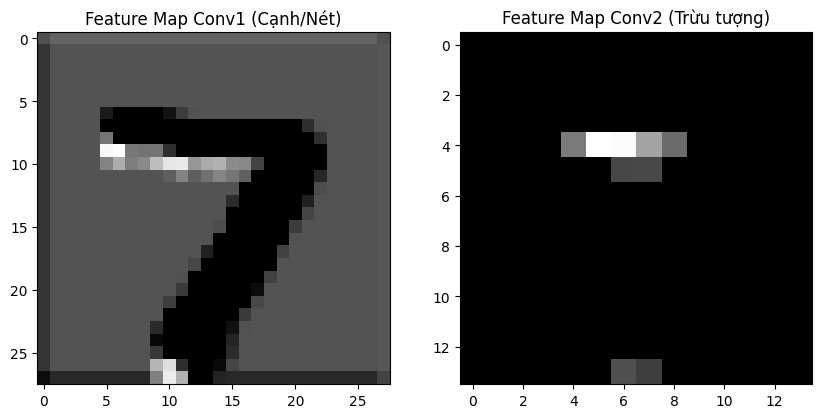

In [4]:
import matplotlib.pyplot as plt

def visualize_features(model, img):
    model.eval()
    with torch.no_grad():
        h1 = torch.relu(model.conv1(img.unsqueeze(0)))
        h1_pooled = model.pool(h1)
        h2 = torch.relu(model.conv2(h1_pooled))
    
    # Vẽ minh họa
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(h1[0, 0].cpu(), cmap='gray')
    ax[0].set_title("Feature Map Conv1 (Cạnh/Nét)")
    ax[1].imshow(h2[0, 0].cpu(), cmap='gray')
    ax[1].set_title("Feature Map Conv2 (Trừu tượng)")
    plt.show()

# Lấy 1 ảnh từ tập test để xem
img, _ = testset[0]
visualize_features(model, img)

- Feature Map Conv1: Thường giữ được cấu trúc của chữ số. Các bộ lọc ở đây đóng vai trò tìm kiếm các cạnh (edge), nét gạch ngang/dọc đơn giản.
- Feature Map Conv2: Trông trừu tượng và khó nhận diện hơn. Ở tầng này, các nét đơn giản từ tầng 1 được kết hợp lại để nhận diện các đặc trưng phức tạp như các góc nhọn, vòng cong khép kín.

### Kết luận tổng quát
- Bài lab này chứng minh rằng CNN vượt trội hơn ANN trong xử lý ảnh nhờ khả năng trích xuất đặc trưng không gian. Việc kết hợp Dropout và Data Augmentation giúp mô hình đạt độ chính xác cao và tránh được hiện tượng quá khớp, giúp mô hình hoạt động tốt ngay cả trên những ảnh chưa từng thấy.